In [15]:
import sys
sys.path.insert(0,'../scripts')
from pycap_for_PESTPP_MOU import postprocess_MOU, plot_pareto, prep_for_viz, create_viz_app, plot_pareto_with_scenarios
from pathlib import Path
from ipywidgets import interact, fixed
import yaml
import matplotlib.pyplot as plt

# Read in one of the configuration files and postprocess it. 
### The `config_file` should be your `secnario_name` + `".yml"` as assigned in the `05_MOU_setup_run.ipynb` notebook. 

In [16]:
configurations = ['depletion_q_baseline_0.0_1.0_0.01', 'depletion_q_Tmin10per_0.0_1.0_0.01', 'depletion_q_Tplus10per_0.0_1.0_0.01', 'depletion_q_Smin10per_0.0_1.0_0.01', 'depletion_q_Splus10per_0.0_1.0_0.01']

config = configurations[-1]  # Select the desired configuration
config_file = config + '.yml'

with open(Path('./configurations') / config_file,'r') as ifp:
    inpars = yaml.safe_load(ifp)
inpars

{'depletion_potential_threshold': 0.01,
 'objectives': 'depletion_q',
 'pump_lbound_fraction': 0.0,
 'pump_ubound_fraction': 1.0,
 'ref_q': 8.6,
 'run_path': '../pycap_runs/pycap_pest/run_depletion_q_Splus10per_0.0_1.0_0.01',
 'scenario_name': 'depletion_q_Splus10per_0.0_1.0_0.01'}

### Below, the `config_file` is processed, beginning the postprocessing

In [17]:
run_path = Path(inpars['run_path'])
run_name = inpars['scenario_name']
pareto_df = postprocess_MOU(run_name, run_path)

In [18]:
pareto_df

,generation,member,Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
0,0,68,4.14838,36.303700,1,1.000000e+30,0.001695,0.001695,1,-999
1,0,152,4.55245,39.085358,1,1.000000e+30,0.004549,0.004549,1,-999
2,0,16,4.26746,38.467534,1,6.312490e-01,0.005091,0.005091,1,-999
3,0,130,4.46413,38.600100,1,5.059650e-01,0.007305,0.007305,1,-999
4,0,95,4.47191,38.900657,1,2.185840e-01,0.007305,0.007305,1,-999
...,...,...,...,...,...,...,...,...,...,...
9661,50,gen=50_member=8503_pso,2.25252,32.630174,1,6.892510e-03,0.007191,0.007191,1,-999
9663,50,gen=50_member=8437_pso,1.88977,31.058988,1,6.851380e-03,0.003153,0.003153,1,-999
9664,50,gen=50_member=8456_pso,1.40150,28.047178,1,6.560590e-03,2.001780,2.001780,1,-999
9665,50,gen=50_member=8518_pso,1.87510,31.043170,1,6.401610e-03,0.003224,0.003224,1,-999


### Next the evolution of the pareto frontier is plotted, over MOU iterations. Check out how the algorithm converges on a well-defined pareto tradeoff frontier

In [19]:
interact(plot_pareto,  currgen=(0,50,1), pareto_df=fixed(pareto_df));

interactive(children=(IntSlider(value=25, description='currgen', max=50), Output()), _dom_classes=('widget-int…

### Where do your scenarios line up? You can provide a list of scenarios that you ran in notebook #3 in the following function to plot a red "x" where each scenario plots up

### NOTE: This only works for the fish vs. receipts case!

In [20]:
dollars=False
# if 'dollar' in inpars['objectives']:
#     dollars = True
# if dollars:
#     plot_pareto_with_scenarios(pareto_df, scenarios=['LPR_Single_Run','LPR_Single_Run70','LPR_Single_Run90'])

### Finally, there is an interactive plot with the pareto frontier on the left and a map of corresponding "optimal" pumping rates on the right. 

### Note - if you get an error about ports being in conflict, change the `port=4242` argument to a different number than `4242`

In [21]:
pareto_df_final, dv_df =  prep_for_viz(pareto_df, 50, run_path, run_name, dollar_objective=dollars)
# app = create_viz_app(pareto_df_final, dv_df)
# app.run(port=4242)

### check out `pareto_df_final` and `dv_df`. What's in these datasets? What further analysis can you perform with this information?

In [22]:
dv_df.T.sample(10)

,well_1013,well_1302,well_1323,well_1486,well_1584,well_1589,well_1643,well_1683,well_1860,well_23610,...,well_93143,well_93349,well_93422,well_93423,well_93424,well_93469,well_93832,well_94302,well_94988,well_95068
gen=36_member=6102_pso,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.078299,...,0.781783,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=31_member=5268_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=43_member=7341_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=32_member=5368_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=45_member=7638_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=35_member=5913_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=41_member=7033_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=47_member=7957_pso,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.53747,...,0.992267,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=42_member=7181_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
gen=45_member=7633_pso,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [23]:
pareto_df_final.columns

Index(['generation', 'member', 'Depletion (cfs)', 'Total Pumping (cfs)',
       'nsga2_front', 'nsga2_crowding_distance', 'spea2_unconstrained_fitness',
       'spea2_constrained_fitness', 'is_feasible', 'feasible_distance'],
      dtype='object')

In [24]:
pareto_df_final.sample(10)

,generation,member,Depletion (cfs),Total Pumping (cfs),nsga2_front,nsga2_crowding_distance,spea2_unconstrained_fitness,spea2_constrained_fitness,is_feasible,feasible_distance
9428,50,gen=30_member=5092_pso,3.65475,36.299467,1,0.006008,0.015010,0.015010,1,-999
9521,50,gen=43_member=7380_pso,3.81679,36.620299,1,0.003970,0.017803,0.017803,1,-999
9568,50,gen=28_member=4720_pso,2.30737,32.858767,1,0.002975,0.009682,0.009682,1,-999
9452,50,gen=43_member=7283_pso,3.30013,35.582274,1,0.005656,0.018918,0.018918,1,-999
9563,50,gen=43_member=7278_pso,2.60804,33.944917,1,0.001538,0.012362,0.012362,1,-999
9528,50,gen=39_member=6673_pso,3.47902,35.963708,1,0.003805,0.016248,0.016248,1,-999
9371,50,gen=45_member=7694_pso,1.27819,26.101911,1,0.008473,0.001121,0.001121,1,-999
9347,50,gen=31_member=5255_pso,3.36688,35.740908,1,0.010095,0.015342,0.015342,1,-999
9364,50,gen=34_member=5697_pso,2.69469,34.173732,1,0.008819,0.009175,0.009175,1,-999
9636,50,gen=50_member=8559_pso,3.87316,36.728580,1,0.002558,0.018760,0.018760,1,-999


In [25]:
new_df = pareto_df_final.copy()
new_df.insert(2, "Streamflow (cfs)", 8.6 - new_df["Depletion (cfs)"])

In [26]:
new_df.columns

Index(['generation', 'member', 'Streamflow (cfs)', 'Depletion (cfs)',
       'Total Pumping (cfs)', 'nsga2_front', 'nsga2_crowding_distance',
       'spea2_unconstrained_fitness', 'spea2_constrained_fitness',
       'is_feasible', 'feasible_distance'],
      dtype='object')

In [27]:
# If we want to, we can save out the pareto tradeoff objectives results to a file. 
# Just change the name below and it will be a new copy!
new_df[['member', 'Total Pumping (cfs)', 'Streamflow (cfs)', 'Depletion (cfs)']].to_csv(f'{config}_tradeoff.csv')

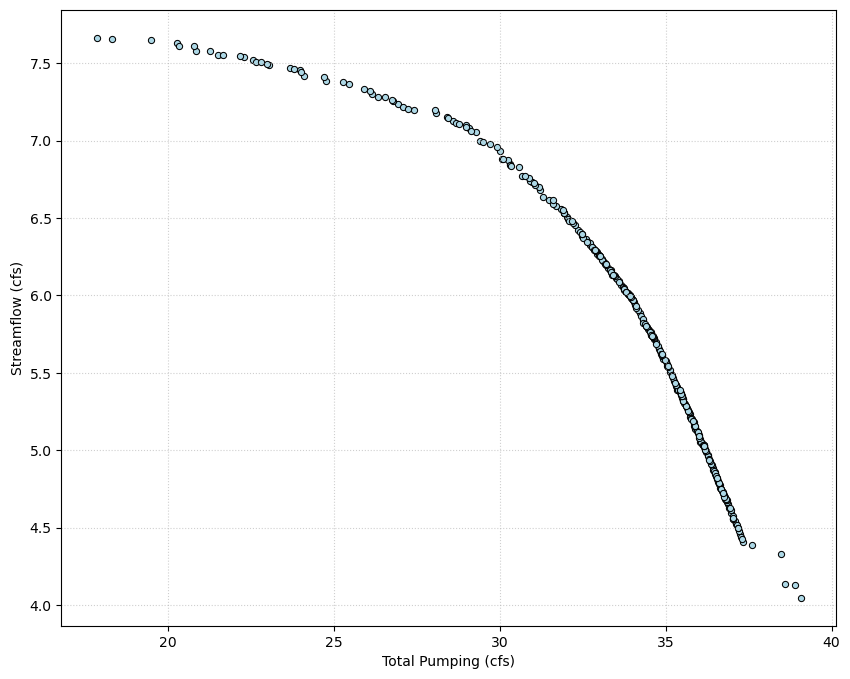

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(new_df["Total Pumping (cfs)"], new_df["Streamflow (cfs)"], marker="o", s=20, c="lightblue", edgecolors="black", linewidths=0.75)
ax.set_xlabel("Total Pumping (cfs)")
ax.set_ylabel("Streamflow (cfs)")
ax.grid(linestyle=":", alpha=0.6)
plt.show()